# Czyszczenie danych

Celem tego etapu jest przygotowanie zbioru danych do dalszej analizy poprzez:
- identyfikację braków danych,
- ocenę typów zmiennych i ich spójności,
- wykrycie potencjalnych wartości odstających,
- określenie mechanizmów braków (MCAR/MAR/MNAR),
- zaplanowanie i wdrożenie strategii imputacji.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

sns.set(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)

In [45]:
sales = pd.read_csv("../Dane/Przetworzone/sales_all_months.csv")

Po wczytaniu danych pierwszym krokiem jest ocena ich kompletności. Analiza braków pozwala zidentyfikować zmienne problematyczne oraz określić, które z nich wymagają imputacji, a które mogą zostać usunięte.

In [64]:
missing_summary = (
    sales.isna()
    .mean()
    .mul(100)
    .round(2)
    .to_frame("missing_percent")
    .query("missing_percent > 0")
    .sort_values("missing_percent", ascending=False)
)

missing_summary.style.format("{:.2f}%").background_gradient(cmap="Reds")


,missing_percent
condition,74.81%
buildingMaterial,39.57%
type,21.61%
floor,17.69%
buildYear,16.47%
hasElevator,4.96%
collegeDistance,2.78%
floorCount,1.22%
clinicDistance,0.37%
restaurantDistance,0.24%


Po zidentyfikowaniu kolumn z największą liczbą braków przechodzimy do oceny struktury zbioru. Sprawdzamy typy zmiennych oraz liczbę niepustych wartości, aby upewnić się, że dane są poprawnie wczytane i gotowe do dalszej diagnostyki.

In [65]:
pd.DataFrame({
    "dtype": sales.dtypes,
    "non_null": sales.notna().sum(),
    "null": sales.isna().sum()
}).sort_values("null", ascending=False)

,dtype,non_null,null
condition,str,49261,146307
buildingMaterial,str,118186,77382
type,str,153307,42261
floor,float64,160974,34594
buildYear,float64,163352,32216
hasElevator,str,185866,9702
collegeDistance,float64,190132,5436
floorCount,float64,193185,2383
clinicDistance,float64,194840,728
restaurantDistance,float64,195089,479


Znając strukturę danych, możemy teraz określić ich skalę. Liczba rekordów i zmiennych pozwala ocenić złożoność zbioru oraz potencjalne wyzwania związane z czyszczeniem i imputacją.


In [66]:
rows, cols = sales.shape
print(f"Liczba rekordów: {rows:,}")
print(f"Liczba zmiennych: {cols}")

Liczba rekordów: 195,568
Liczba zmiennych: 29


Zbiór danych zawiera dużą liczbę obserwacji, co umożliwia przeprowadzenie wiarygodnej analizy statystycznej. Kolejnym krokiem jest analiza statystyk opisowych zmiennych numerycznych. Pozwala to ocenić rozkłady, wykryć wartości odstające oraz zrozumieć ogólną charakterystykę danych liczbowych.


In [67]:
sales.describe().T.round(2).style.background_gradient(cmap="Blues")

,count,mean,std,min,25%,50%,75%,max
squareMeters,195568.000000,58.700000,21.410000,25.000000,44.000000,54.600000,68.550000,150.000000
rooms,195568.000000,2.680000,0.920000,1.000000,2.000000,3.000000,3.000000,6.000000
floor,160974.000000,3.330000,2.530000,1.000000,2.000000,3.000000,4.000000,29.000000
floorCount,193185.000000,5.310000,3.310000,1.000000,3.000000,4.000000,6.000000,29.000000
buildYear,163352.000000,1985.980000,33.810000,1850.000000,1967.000000,1994.000000,2016.000000,2024.000000
latitude,195568.000000,52.030000,1.340000,49.980000,51.110000,52.190000,52.410000,54.610000
longitude,195568.000000,19.470000,1.780000,14.450000,18.520000,19.900000,20.990000,23.210000
centreDistance,195568.000000,4.350000,2.840000,0.010000,2.010000,3.980000,6.150000,16.940000
poiCount,195568.000000,20.670000,24.330000,0.000000,7.000000,14.000000,24.000000,212.000000
schoolDistance,195400.000000,0.410000,0.460000,0.000000,0.180000,0.290000,0.470000,4.950000


Statystyki opisowe zmiennych numerycznych ujawniają podstawowe właściwości danych, takie jak zakres wartości, średnia, mediana oraz rozrzut. Pozwala to wstępnie ocenić rozkłady zmiennych oraz wykryć potencjalne wartości odstające. W analizowanych danych nie widać nieścisłości. Po analizie zmiennych numerycznych przechodzimy do zmiennych kategorycznych. Ich struktura i najczęściej występujące wartości są kluczowe przy planowaniu dalszego czyszczenia oraz przygotowywaniu danych do modelowania.


In [68]:
sales.describe(include="object").T.style.background_gradient(cmap="Purples")

C:\Users\Użytkownik\AppData\Local\Temp\ipykernel_21572\794359403.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  sales.describe(include="object").T.style.background_gradient(cmap="Purples")


,count,unique,top,freq
id,195568,92967,d59165364f1c4b3d658890e808e7d77c,11
city,195568,15,warszawa,59246
type,153307,3,blockOfFlats,91368
ownership,195568,3,condominium,176123
buildingMaterial,118186,2,brick,91899
condition,49261,2,premium,27869
hasParkingSpace,195568,2,no,142410
hasBalcony,195568,2,yes,112049
hasElevator,185866,2,no,93662
hasSecurity,195568,2,no,173630


Statystyki zmiennych kategorycznych pokazują najczęściej występujące wartości oraz liczbę unikalnych kategorii. Informacje te są kluczowe przy planowaniu dalszego czyszczenia danych oraz przygotowywaniu zmiennych do modelowania.  Aby lepiej zrozumieć rozmieszczenie braków w zbiorze, wizualizujemy je za pomocą narzędzi missingno. Pozwala to ocenić, czy braki są losowe, czy też tworzą wyraźne wzorce.


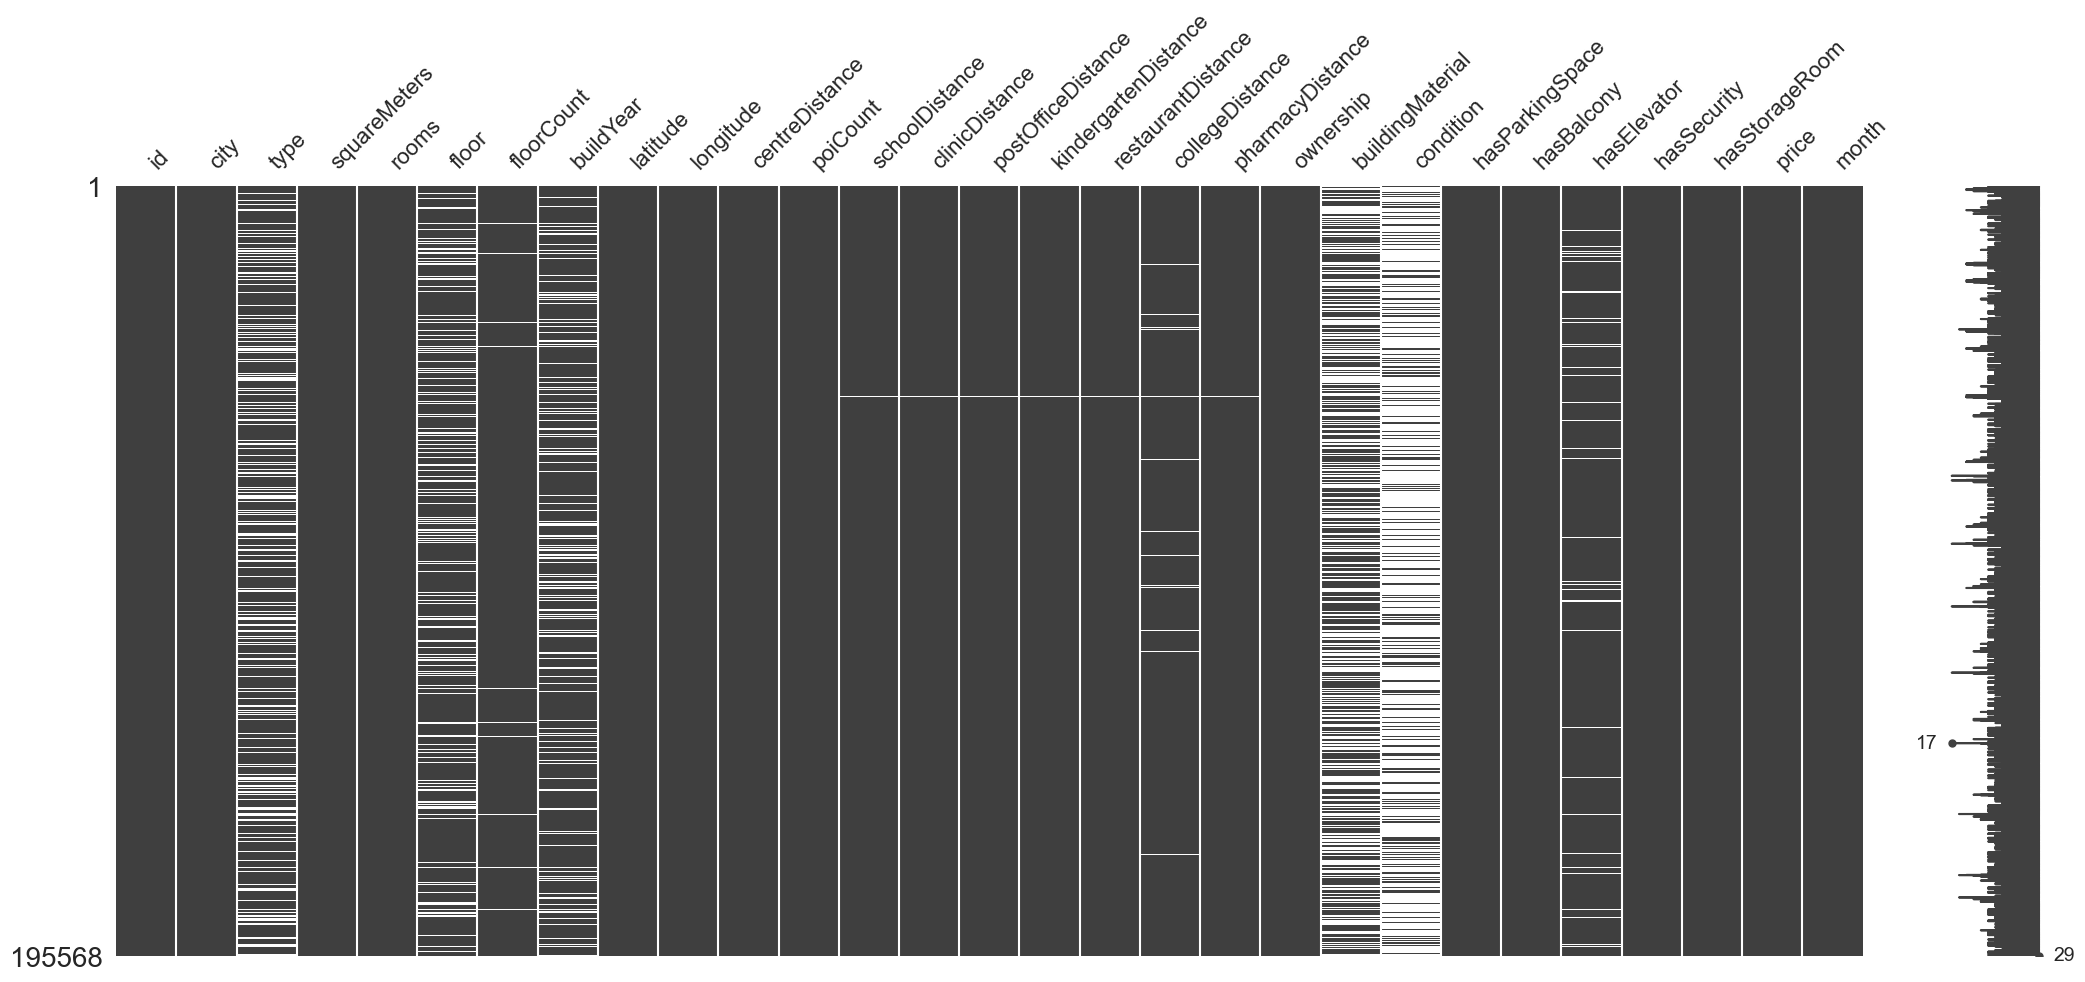

In [69]:
msno.matrix(sales)
plt.show()

Część braków występuje w konkretnych kolumnach. Jednak sama wizualizacja rozmieszczenia braków nie wystarcza — ważne jest również sprawdzenie, czy braki współwystępują między zmiennymi. W tym celu analizujemy korelację braków.


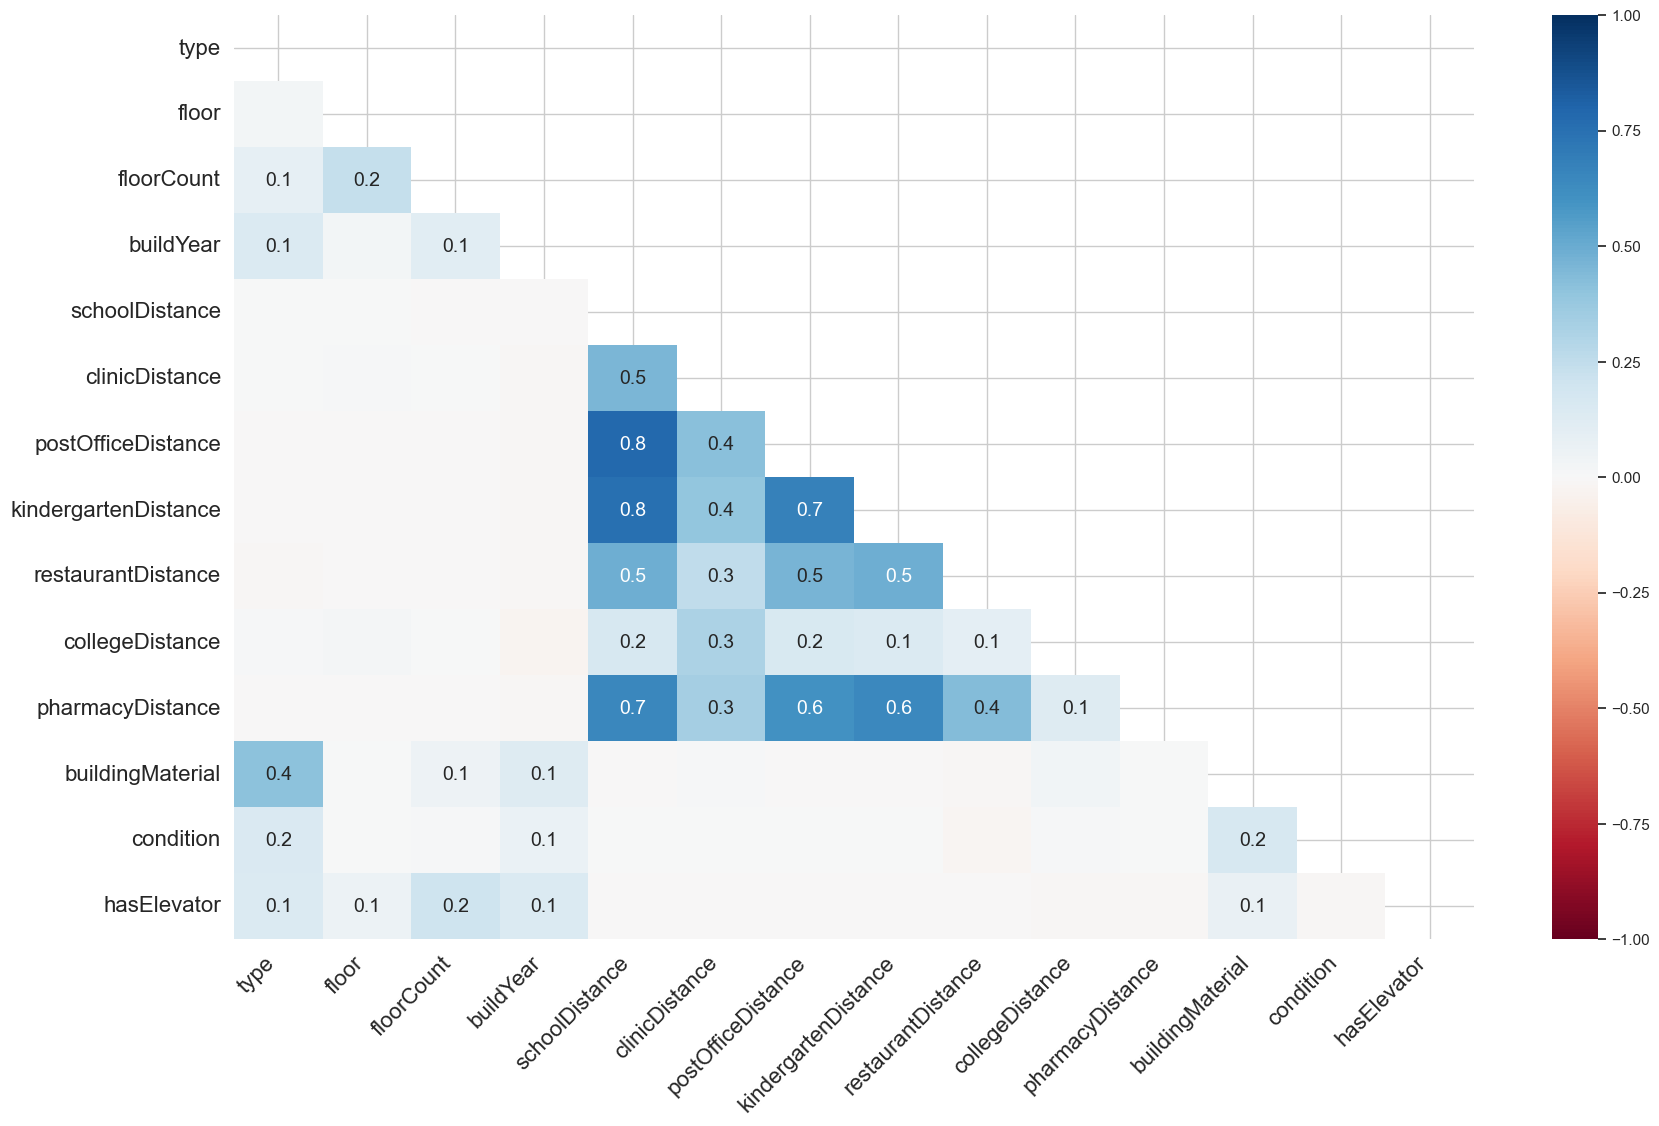

In [70]:
msno.heatmap(sales)
plt.show()

Na podstawie wizualizacji i korelacji braków możemy przejść do szczegółowej analizy mechanizmów braków w poszczególnych zmiennych. Pozwoli to określić, które braki są losowe (MCAR), zależne od innych zmiennych (MAR), a które wynikają z celowego pomijania informacji (MNAR).

**Condition** - sporo braków - to raczej nie jest przykładowy brak techniczny. Stan mieszkania może być informacją, którą sprzedający może nie podawać. Możemy mieć do czynienia z MNAR (Missing Not At Random): mieszkanie w dobrym stanie - właściciel wpisuje, mieszkanie wymagające remontu - właściciel pomija fakt. Ta zmienna nie nadaje się do imputacji.

**BuildingMaterial** - prawdopodobnie zależy od typu nieruchomości. Sprawdzamy procent braków w obrębie typu nieruchomości. Szukamy odpowiedzi na pytanie "Dla każdego typu mieszkania: jaki procent rekordów ma podany materiał budynku, a jaki procent ma brak?".

In [60]:
pd.crosstab(
    sales["type"],
    sales["buildingMaterial"].isna(),
    normalize="index"
).style.format("{:.1%}")

buildingMaterial,False,True
type,,
apartmentBuilding,100.0%,0.0%
blockOfFlats,51.3%,48.7%
tenement,100.0%,0.0%


Wszystkie rekordy apartmentBuilding i tenement nie mają braków. Wszystkie braki danych tej zmiennej pochodzą z blockOfFlats (48,7% mieszkań). Brak jest zależny od innej zmiennej (type) - mechanizm MAR (Missing at Random).

**Type** - wydaje się losowy. Tutaj możemy prawdopodobnie imputować modą albo stworzyć kategorię Unknwown.

**Floor i FloorCount** - czy braki korelują ze sobą? Jeśli braki w floor pokrywają się z brakami w floorCount, to może to być MAR (wspólna przyczyna). Jeśli są rozproszone niezależnie, to MCAR (losowe).

In [76]:
pd.crosstab(
    sales["floor"].isna(),
    sales["floorCount"].isna(),
    margins=True
)

floorCount,False,True,All
floor,,,
False,160974,0,160974
True,32211,2383,34594
All,193185,2383,195568


Nigdy nie ma sytuacji, że floor jest, a floorCount brakuje. 32211 rekordów - gdy floor brakuje, ale floorCount jest (prawie 94% z brakami floor). 2383 rekordy - gdy oba brakują (prawie 7% z brakami floor). To jest MAR (Missing At Random). Braki nie są losowe - są powiązane. Gdy brakuje floor, zwykle floorCount jest dostępny (może być wspólna przyczyna). W ramach czyszczenia danych, tam gdzie floor brakuje ale floorCount jest - można imputować floor z floorCount lub średnią wg typu. Gdzie oba brakują (2383) - usunąć lub imputować ostrożniej.

**BuildYear** - czy braki są zależne od typu nieruchomości?

In [78]:
pd.crosstab(
    sales["type"],
    sales["buildYear"].isna(),
    normalize="index"
).style.format("{:.1%}")

buildYear,False,True
type,,
apartmentBuilding,93.2%,6.8%
blockOfFlats,86.0%,14.0%
tenement,80.3%,19.7%


Kamienice (tenement) mają ~20% braków - to najstarsza zabudowa, może nie mieć dokumentacji roku budowy.
Bloki mieszkalne mają 14% braków - pośrednio. Budynki apartamentowe mają najmniej braków (7%) - to nowsze/lepiej udokumentowane. To nie jest losowe - to MAR. Braki zależą od typu nieruchomości. Można imputować buildYear medianą lub trybem wg typu (bo MAR i imputacja wg grupy jest uzasadniona).

**hasElevator** - czy braki są zależne od typu nieruchomości?

In [79]:
pd.crosstab(
    sales["type"],
    sales["hasElevator"].isna(),
    normalize="index"
).style.format("{:.1%}")

hasElevator,False,True
type,,
apartmentBuilding,99.3%,0.7%
blockOfFlats,97.1%,2.9%
tenement,92.5%,7.5%


Bloki mieszkalne (blockOfFlats) mają 2.9% braków w hasElevator, kamienice (tenement) 7.5%, a budynki apartamentowe (apartmentBuilding) tylko 0.7%. To pokazuje wyraźny wzorzec: braki rosną wraz z typem zabudowy, a najwięcej braków występuje w kamienicach.

To sugeruje zależność braków od typu nieruchomości, choć jest ona słabsza niż w przypadku buildYear. Sprawdzamy powiązanie braków z brakami w innych zmiennych.

In [80]:
elevator_missing = sales[sales['hasElevator'].isna()]
print(f"\nZ {len(elevator_missing)} rekordów z brakami w hasElevator:\n")

cols_to_check = ['condition', 'buildingMaterial', 'buildYear', 'floor', 'floorCount']
for col in cols_to_check:
    missing_count = elevator_missing[col].isna().sum()
    pct = (missing_count / len(elevator_missing) * 100)
    print(f"  {col:20} - braki: {missing_count:5} ({pct:5.1f}%)")


Z 9702 rekordów z brakami w hasElevator:

  condition            - braki:  7032 ( 72.5%)
  buildingMaterial     - braki:  5437 ( 56.0%)
  buildYear            - braki:  3814 ( 39.3%)
  floor                - braki:  2672 ( 27.5%)
  floorCount           - braki:  1066 ( 11.0%)


Wyraźnie widać, że braki w hasElevator są  powiązane z brakami w condition (72.5%), buildingMaterial (56%) i buildYear (39.3%). To nie są niezależne braki losowe. Dla mieszkań bez informacji o windzie często jednocześnie brakuje danych o stanie, materiale i roku budowy budynku. 

**Wniosek:** Braki w hasElevator pochodzą z tego samego źródła co braki w charakterystykach budynku - to niekompletne dane od ogłoszeniodawcy lub braki w bazie źródłowej. Można je traktować jako MAR (Missing At Random) warunkowe względem typu nieruchomości. Dla imputacji można rozważyć median/modę wg typu zabudowy.

Teraz analizujemy wszystkie kolumny typu `*Distance` razem: `collegeDistance`, `clinicDistance`, `restaurantDistance`, `pharmacyDistance`, `postOfficeDistance`, `kindergartenDistance` i `schoolDistance`. Sprawdzimy:
- ile braków jest w każdej kolumnie,
- czy braki współwystępują między kolumnami distance,
- oraz czy występują wzorce braków zależne od typu nieruchomości.

In [63]:
# --- Lista kolumn distance ---
distance_cols = [
    'collegeDistance',
    'clinicDistance',
    'restaurantDistance',
    'pharmacyDistance',
    'postOfficeDistance',
    'kindergartenDistance',
    'schoolDistance'
]

# --- Maska braków ---
missing_distance = sales[distance_cols].isna()

# ============================================================
# 1) Braki w kolumnach distance — ładna tabela
# ============================================================

missing_summary = (
    missing_distance.mean()
    .mul(100)
    .round(2)
    .to_frame("missing_percent")
    .query("missing_percent > 0")
    .sort_values("missing_percent", ascending=False)
)

display(
    missing_summary.style
    .format("{:.2f}%")
    .background_gradient(cmap="Reds")
    .set_caption("Braki w kolumnach distance (%)")
)

# ============================================================
# 2) Korelacja braków — macierz z gradientem
# ============================================================

corr_missing = missing_distance.corr().round(2)

display(
    corr_missing.style
    .background_gradient(cmap="Blues")
    .set_caption("Korelacja braków między kolumnami distance")
)

# ============================================================
# 3) Braki distance wg typu nieruchomości — tabela z gradientem
# ============================================================

missing_by_type = (
    missing_distance.groupby(sales["type"])
    .mean()
    .mul(100)
    .round(2)
)

display(
    missing_by_type.style
    .format("{:.2f}%")
    .background_gradient(cmap="Purples")
    .set_caption("Procent braków distance wg typu nieruchomości")
)


,missing_percent
collegeDistance,2.78%
clinicDistance,0.37%
restaurantDistance,0.24%
pharmacyDistance,0.14%
postOfficeDistance,0.13%
kindergartenDistance,0.11%
schoolDistance,0.09%


,collegeDistance,clinicDistance,restaurantDistance,pharmacyDistance,postOfficeDistance,kindergartenDistance,schoolDistance
collegeDistance,1.000000,0.320000,0.100000,0.130000,0.160000,0.140000,0.170000
clinicDistance,0.320000,1.000000,0.260000,0.340000,0.420000,0.400000,0.460000
restaurantDistance,0.100000,0.260000,1.000000,0.430000,0.460000,0.490000,0.490000
pharmacyDistance,0.130000,0.340000,0.430000,1.000000,0.610000,0.640000,0.650000
postOfficeDistance,0.160000,0.420000,0.460000,0.610000,1.000000,0.680000,0.790000
kindergartenDistance,0.140000,0.400000,0.490000,0.640000,0.680000,1.000000,0.750000
schoolDistance,0.170000,0.460000,0.490000,0.650000,0.790000,0.750000,1.000000


,collegeDistance,clinicDistance,restaurantDistance,pharmacyDistance,postOfficeDistance,kindergartenDistance,schoolDistance
type,,,,,,,
apartmentBuilding,2.81%,0.57%,0.49%,0.23%,0.20%,0.23%,0.13%
blockOfFlats,3.38%,0.38%,0.14%,0.16%,0.12%,0.09%,0.08%
tenement,0.36%,0.07%,0.42%,0.06%,0.07%,0.03%,0.02%


Analiza braków w zmiennych odległościowych potwierdza, że braki te mają charakter MAR i współwystępują między kolumnami. Uzasadnia to zastosowanie wielowymiarowej imputacji, która uwzględnia zależności między zmiennymi.

## Podsumowanie

Na podstawie przeprowadzonej diagnostyki opracowano strategię czyszczenia danych, obejmującą usunięcie jednej zmiennej, imputację zmiennych zależnych (MAR) oraz zastosowanie wielowymiarowej imputacji dla zmiennych odległościowych.

W ramach czyszczenia danych:
- usunięto zmienną `condition` (MNAR, 75% braków),
- imputowano `buildingMaterial` metodą hot‑deck dla blockOfFlats,
- imputowano `floor` z `floorCount`,
- imputowano zmienne liczbowe medianą wg typu,
- imputowano zmienne kategoryczne jako `Unknown`,
- zastosowano IterativeImputer dla zmiennych distance,
- zapisano finalny zbiór `sales_clean.csv`.

Zbiór jest kompletny i gotowy do dalszej analizy.



In [42]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

raw_path = Path("../Dane/Przetworzone/sales_all_months.csv")
out_path = Path("../Dane/Czyste/sales_clean.csv")

sales = pd.read_csv(raw_path)
sales_clean = sales.copy()

distance_cols = [
    "collegeDistance",
    "clinicDistance",
    "restaurantDistance",
    "pharmacyDistance",
    "postOfficeDistance",
    "kindergartenDistance",
    "schoolDistance",
]

# 1. Usuwamy condition (75% braków, MNAR)
if "condition" in sales_clean.columns:
    sales_clean = sales_clean.drop(columns=["condition"])

# 2. buildingMaterial — imputacja tylko dla blockOfFlats (hot-deck)
if "buildingMaterial" in sales_clean.columns and "type" in sales_clean.columns:
    block_mask = sales_clean["type"].eq("blockOfFlats")
    missing_mask = block_mask & sales_clean["buildingMaterial"].isna()

    if missing_mask.any():
        observed = sales_clean.loc[
            block_mask & sales_clean["buildingMaterial"].notna(),
            ["city", "ownership", "buildingMaterial"],
        ]
        rng = np.random.default_rng(42)
        filled = []
        for _, row in sales_clean.loc[missing_mask, ["city", "ownership"]].iterrows():
            city = row["city"]
            ownership = row["ownership"]
            candidates = observed.loc[
                (observed["city"].fillna("Unknown") == (city if pd.notna(city) else "Unknown")),
                "buildingMaterial",
            ]
            
            if candidates.empty:
                candidates = observed["buildingMaterial"]
            filled.append(candidates.sample(1, random_state=int(rng.integers(0, 100000))).iloc[0])
        sales_clean.loc[missing_mask, "buildingMaterial"] = filled

sales_clean["buildingMaterial"] = sales_clean["buildingMaterial"].fillna("Unknown")

# 3. type — imputacja modą
if "type" in sales_clean.columns:
    mode_type = sales_clean["type"].mode()[0]
    sales_clean["type"] = sales_clean["type"].fillna(mode_type)

# 4. floor imputujemy z floorCount (zgodnie z analizą MAR)
if "floor" in sales_clean.columns and "floorCount" in sales_clean.columns:
    mask = sales_clean["floor"].isna() & sales_clean["floorCount"].notna()
    sales_clean.loc[mask, "floor"] = sales_clean.loc[mask, "floorCount"] - 1

# 5. Numeric columns — imputacja medianą wg typu
numeric_cols = ["buildYear", "floor", "floorCount", "squareMeters", "rooms", "poiCount"]
for col in numeric_cols:
    if col in sales_clean.columns:
        if "type" in sales_clean.columns:
            sales_clean[col] = sales_clean.groupby("type")[col].transform(
                lambda s: s.fillna(s.median())
            )
        sales_clean[col] = sales_clean[col].fillna(sales_clean[col].median())

# 6. hasElevator — imputacja modą w obrębie typu (zgodnie z analizą MAR)
if "hasElevator" in sales_clean.columns:
    sales_clean["hasElevator"] = sales_clean.groupby("type")["hasElevator"].transform(
        lambda s: s.fillna(s.mode()[0] if not s.mode().empty else "Unknown")
    )

# 7. Pozostałe kategorie — Unknown
categorical_cols = [
    "city", "ownership", "hasParkingSpace", "hasBalcony",
    "hasSecurity", "hasStorageRoom", "month"
]

for col in categorical_cols:
    if col in sales_clean.columns:
        sales_clean[col] = sales_clean[col].fillna("Unknown")

# 8. Distance — IterativeImputer
if all(col in sales_clean.columns for col in distance_cols):
    feature_cols = [
        "squareMeters",
        "rooms",
        "floor",
        "poiCount",
        "buildYear",
        "type",
        "city",
        "ownership",
        "buildingMaterial",
        "hasElevator",
        "hasParkingSpace",
        "hasBalcony",
        "hasSecurity",
        "hasStorageRoom",
    ]
    impute_frame = sales_clean[distance_cols + [col for col in feature_cols if col in sales_clean.columns]].copy()

    cat_cols = [
        col
        for col in [
            "type",
            "city",
            "ownership",
            "buildingMaterial",
            "hasElevator",
            "hasParkingSpace",
            "hasBalcony",
            "hasSecurity",
            "hasStorageRoom",
        ]
        if col in impute_frame.columns
    ]

    for col in cat_cols:
        impute_frame[col] = impute_frame[col].fillna("Unknown")

    impute_frame = pd.get_dummies(impute_frame, columns=cat_cols, dummy_na=False)

    for col in impute_frame.columns:
        if impute_frame[col].isna().any():
            impute_frame[col] = impute_frame[col].fillna(impute_frame[col].median())

    imputer = IterativeImputer(random_state=0, max_iter=25, initial_strategy="median")
    imputed = pd.DataFrame(
        imputer.fit_transform(impute_frame),
        columns=impute_frame.columns,
        index=sales_clean.index,
    )
    sales_clean[distance_cols] = imputed[distance_cols]

# 9. Ostateczne uzupełnienie braków
for col in sales_clean.columns:
    if sales_clean[col].isna().any():
        if pd.api.types.is_numeric_dtype(sales_clean[col]):
            sales_clean[col] = sales_clean[col].fillna(sales_clean[col].median())
        else:
            sales_clean[col] = sales_clean[col].fillna("Unknown")

# 10. Zapis
out_path.parent.mkdir(parents=True, exist_ok=True)
sales_clean.to_csv(out_path, index=False)

print("Zapisano", len(sales_clean), "rekordów do", out_path)
print("Pozostałe braki:", sales_clean.isna().sum().sum())

Zapisano 195568 rekordów do ..\Dane\Czyste\sales_clean.csv
Pozostałe braki: 0


Po wykonaniu wszystkich kroków czyszczenia zbiór danych jest kompletny, spójny i gotowy do dalszej analizy. Oczyszczony zbiór zapisano do pliku `sales_clean.csv`, który stanowi podstawę do kolejnych etapów analizy.

